In [1]:
import numpy as np
import emcee 
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

In [3]:
transient = np.load('transient.npy')
time = transient[:, 0]
flux = transient[:, 1]
errs = transient[:, 2]

In [4]:
def mymodel(params, t):
    b, t0, A, alpha = params
    y = np.zeros(len(t))
    cond = t<t0
    y[cond] += b
    y[~cond] += b+A*np.exp(-alpha*(t[~cond]-t0))
    return y

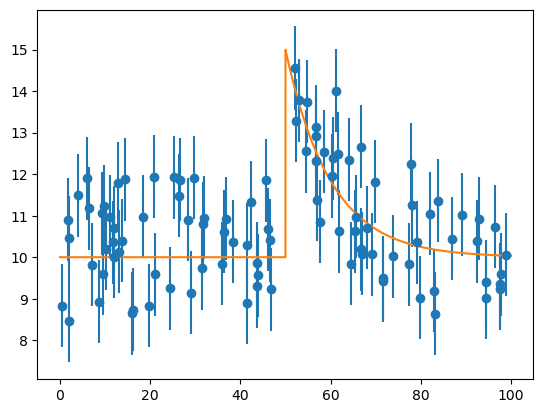

In [6]:
test_params = (10, 50, 5, 0.1)
xarr = np.linspace(0, 100, 10000)
fig, ax = plt.subplots()
plt.errorbar(time, flux, yerr=errs, fmt='o')
plt.plot(xarr, mymodel(test_params, xarr))

In [7]:
def log_lik(params, datatable):
    
    times, fluxes, sigma_y = datatable.T
    y_fit = mymodel(params, times)
    
    return -0.5 * np.sum((fluxes-y_fit)**2 / sigma_y**2 ) 

def log_prior(params):
    b, t0, A, alpha = params
    zero = 0
    bmax = 50
    t0max = 100
    alphamin = np.exp(-5)
    alphamax = np.exp(5)

    if zero < b < bmax and zero < A < bmax and zero < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 - np.log(alpha)

    else:
        return -np.inf

def log_post(params, datatable):
    return log_lik(params, datatable) + log_prior(params)

In [8]:
nsteps = 20000
nparams = 4
nwalkers = 20
starting_guesses = test_params + 0.1*np.random.randn(nwalkers, nparams)

In [9]:
sampler = emcee.EnsembleSampler(nwalkers, nparams, log_post, args=[transient])
sampler.run_mcmc(starting_guesses, nsteps);

C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [10]:
tau = sampler.get_autocorr_time()
print(tau)

[54.78639651 74.52204401 71.37230589 58.67823453]


In [53]:
# first open the chain to see what the burn time roughly is

chain = sampler.get_chain(flat=True)
b_chain = chain[:, 0]
t0_chain = chain[:, 1]
A_chain = chain[:, 2]
alpha_chain = chain[:, 3]

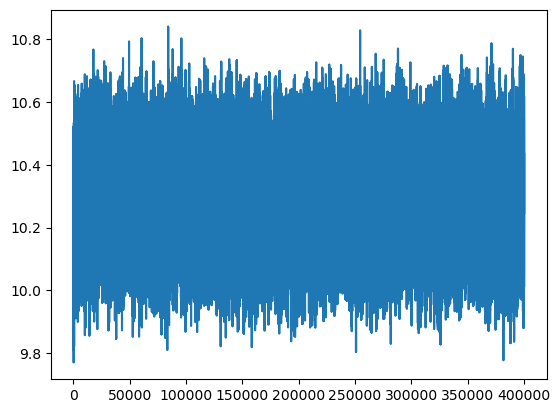

In [15]:
plt.plot(b_chain)

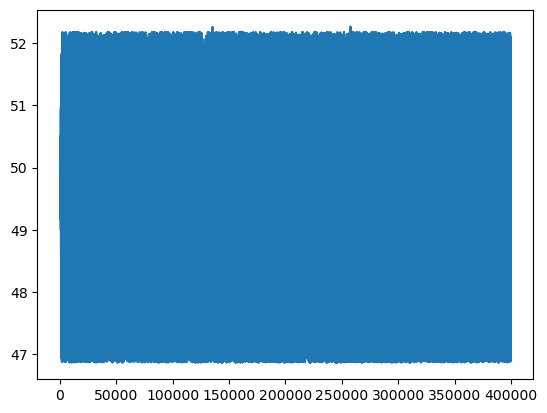

In [16]:
plt.plot(t0_chain)

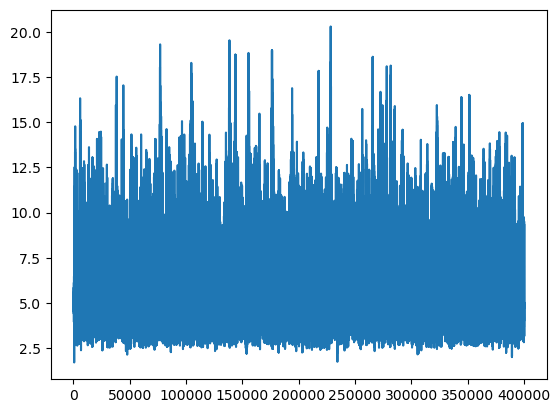

In [17]:
plt.plot(A_chain)

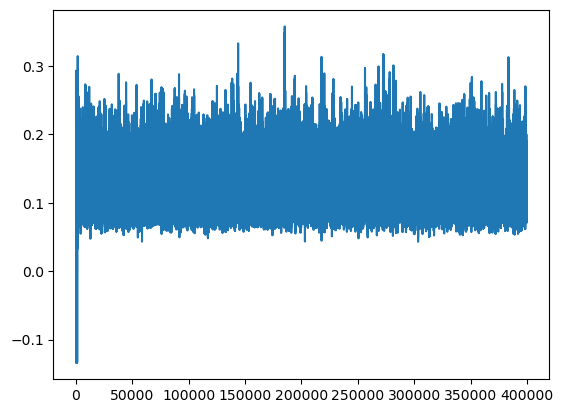

In [18]:
plt.plot(alpha_chain)

In [54]:
burn = 1500
burnt_b = b_chain[burn:]
burnt_t0 = t0_chain[burn:]
burnt_A = A_chain[burn:]
burnt_alpha = alpha_chain[burn:]

burnt_chains = [burnt_b, burnt_t0, burnt_A, burnt_alpha]

new_chains = []

for t in range(4):
    new_chain = []
    autoct = int(tau[t])
    i = 0
    
    while i*autoct < len(burnt_chains[t]):
        new_chain.append(burnt_chains[t][i*autoct])
        i += 1
    
    new_chains.append(new_chain)    

In [55]:
new_b = new_chains[0]
new_t0 = new_chains[1]
new_A = new_chains[2]
new_alpha = new_chains[3]

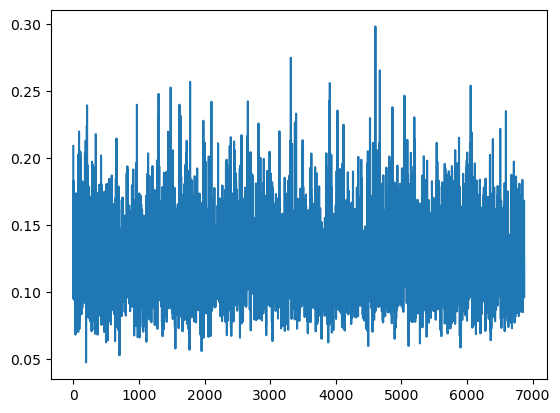

In [59]:
plt.plot(new_alpha)